In [1]:
import os
import pandas as pd
import numpy as np

import pickle

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, mean_squared_error

import shap

from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings('ignore')

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Leitura dos artefatos

In [2]:
model = pickle.load(
    open('../models/wrapped/model_pipeline_prod.pkl', 'rb')
)
model


Pipeline(steps=[('json_to_df', Json parser),
                ('seletor_1',
                 Feature Selector. Mode: train. Features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'contact', 'contacts_tendency', 'default', 'emp.var.rate', 'employment_status', 'euribor3m', 'job', 'month', 'nr.employed', 'pdays', 'poutcome', 'previous', 'quarter', 'was_contacted_before']),
                ('cria_features', BuildFeatur...
                 Feature Selector. Mode: train. Features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'contact', 'contacts_tendency', 'default', 'emp.var.rate', 'employment_status', 'euribor3m', 'job', 'month', 'nr.employed', 'pdays', 'poutcome', 'previous', 'quarter', 'was_contacted_before']),
                ('modelo',
                 LGBMClassifier(eval_metric='auc',
                                learning_rate=0.026594346401661702, max_depth=6,
                                min_child_samples=95, n_estimators=304,
                                num_leaves=14, random_state=12))])

# Classificação

## Leitura das bases (treino e teste)

In [3]:
df_treino = pd.read_csv(os.path.join('..', 'data', 'train_test', 'train.csv'))

print(df_treino.shape)
df_treino.head()

(32940, 25)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,quarter,contacts_tendency,employment_status,was_contacted_before,y
0,31,admin.,single,university.degree,no,no,no,cellular,sep,fri,...,-3.4,92.379,-29.8,0.803,5017.5,3Q,0.0,employed,False,0
1,39,housemaid,married,high.school,no,yes,no,telephone,may,fri,...,1.1,93.994,-36.4,4.857,5191.0,2Q,0.0,employed,False,0
2,34,entrepreneur,married,professional.course,no,yes,no,cellular,jul,thu,...,1.4,93.918,-42.7,4.958,5228.1,3Q,0.0,employed,False,0
3,36,technician,married,basic.9y,unknown,no,no,telephone,may,tue,...,1.1,93.994,-36.4,4.856,5191.0,2Q,0.0,employed,False,0
4,25,student,single,unknown,unknown,yes,no,cellular,aug,fri,...,-2.9,92.201,-31.4,0.825,5076.2,3Q,0.0,not_employed,False,0


In [4]:
df_teste = pd.read_csv(os.path.join('..', 'data', 'train_test', 'test.csv'))

print(df_teste.shape)
df_teste.head()

(8236, 25)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,quarter,contacts_tendency,employment_status,was_contacted_before,y
0,27,student,single,high.school,unknown,yes,no,telephone,may,thu,...,1.1,93.994,-36.4,4.860,5191.0,2Q,0.0,not_employed,False,0
1,60,admin.,divorced,professional.course,no,yes,no,cellular,sep,wed,...,-1.1,94.199,-37.5,0.886,4963.6,3Q,1.0,employed,False,1
2,51,blue-collar,married,high.school,no,no,no,telephone,may,fri,...,1.1,93.994,-36.4,4.855,5191.0,2Q,0.0,employed,False,0
3,39,blue-collar,single,unknown,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,2Q,0.0,employed,False,0
4,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,fri,...,1.1,93.994,-36.4,4.864,5191.0,2Q,0.0,employed,False,0


In [5]:
seletor = pickle.load(
    open(os.path.join('..', 'models', 'encoders', 'seletor_2.pkl'), 'rb')
)

## Scoring

In [6]:
df_treino['score'] = (model.predict_proba(df_treino)[:,1]*1000).astype(int)
df_teste['score'] = (model.predict_proba(df_teste)[:,1]*1000).astype(int)

## Evaluation

In [7]:
roc_auc_score(
    df_treino['y'],
    df_treino['score']/1000
)

0.8239874524046548

In [8]:
roc_auc_score(
    df_teste['y'],
    df_teste['score']/1000
)

0.797165019713367

## Análise de resultados

In [9]:
print(hasattr(model[-1], 'booster_'))  # True se o modelo estiver treinado


True


In [10]:
booster = model[-1].booster_
importance = booster.feature_importance(importance_type='split')  

df_imp = pd.DataFrame({
    'feature': seletor.features,
    'imp': importance
}).sort_values(by='imp', ascending=False)


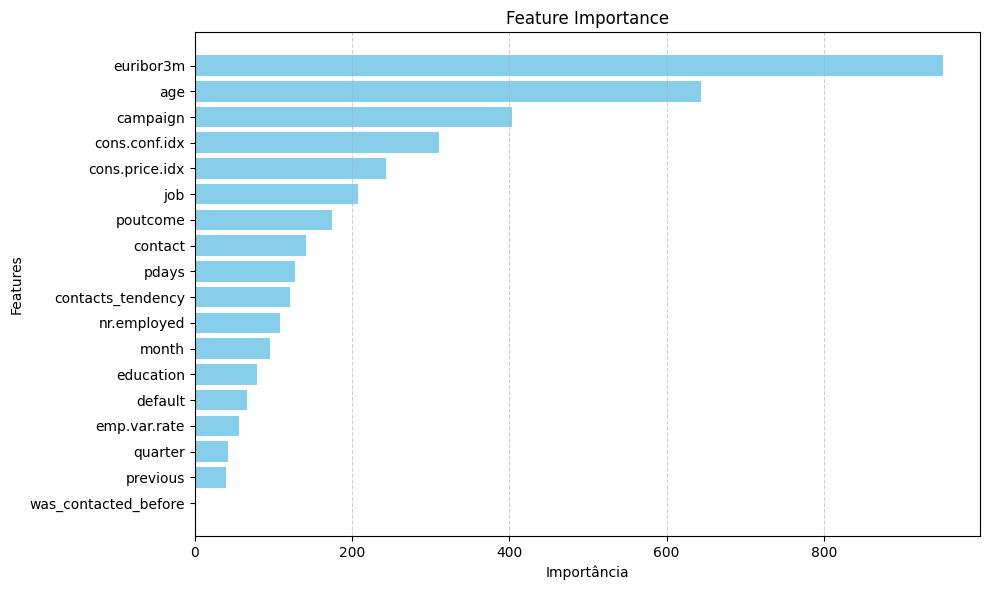

In [11]:
plt.figure(figsize=(10, 6))

plt.barh(df_imp['feature'], df_imp['imp'], color = 'skyblue')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.grid(axis = 'x', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

In [12]:
df_treino_encoded = pd.read_csv(os.path.join('..', 'data', 'train_test', 'train_encoded.csv'))
sample_train = df_treino_encoded[seletor.features].sample(frac = 0.3, random_state=98)

 98%|===================| 9714/9882 [00:29<00:00]        

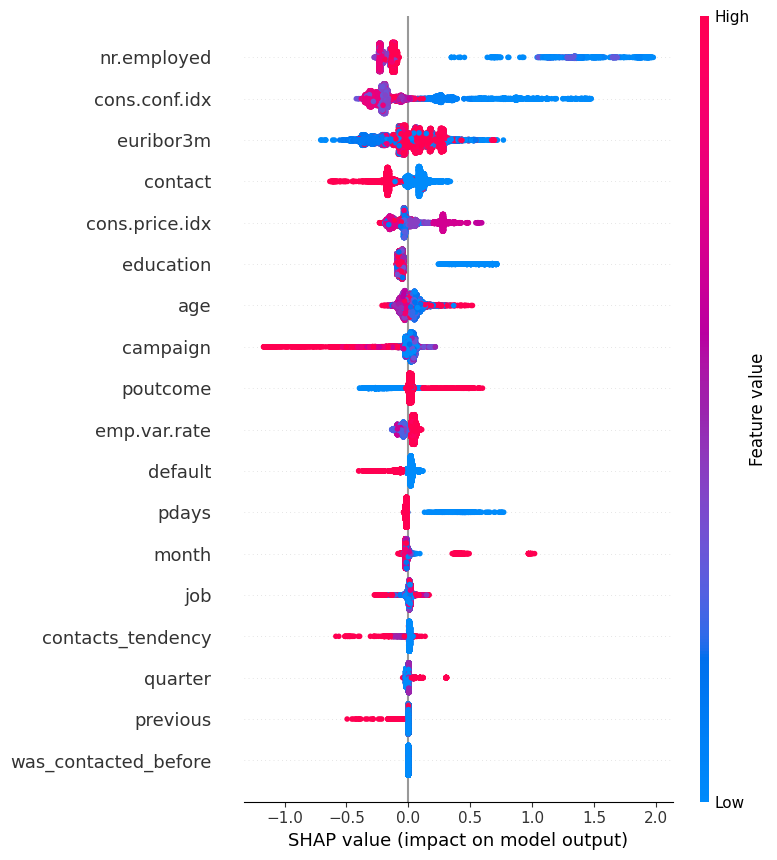

In [13]:
explainer = shap.Explainer(model[-1], sample_train)
shap_values = explainer(sample_train)

plt.figure(figsize = (10, 6))
shap.summary_plot(shap_values, sample_train)